In [ ]:
# Sales Prediction Using Python

## OASIS Infobyte – Data Science Internship

### Task 5: Sales Prediction Using Python

### Objective
The objective of this project is to build regression models that predict product
sales based on advertising expenditure across different media channels such as
TV, Radio, and Newspaper.

The project includes data exploration, visualization, model training,
performance evaluation, model comparison, residual analysis, and interpretation
of feature importance.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("Advertising.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (200, 5)


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
print("Missing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

Missing Values:


,Missing Values
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
display(df.describe())

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [8]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']


In [9]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

# Remove rows containing missing values
df = df.dropna().copy()

# Reset index
df.reset_index(drop=True, inplace=True)

print("Final Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Final Dataset Shape: (200, 5)

Missing Values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

Duplicate Rows: 0


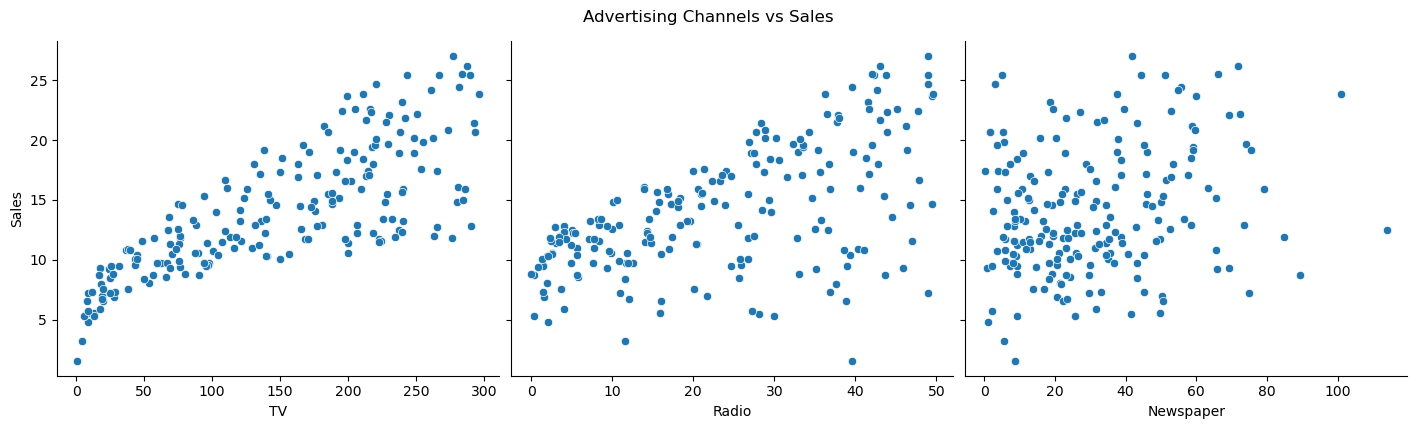

In [10]:
sns.pairplot(
    df,
    x_vars=["TV", "Radio", "Newspaper"],
    y_vars=["Sales"],
    height=4,
    aspect=1.2
)

plt.suptitle(
    "Advertising Channels vs Sales",
    y=1.05
)

plt.show()

In [ ]:
### Observation

The pairplot shows the relationship between advertising expenditure on TV, Radio,
and Newspaper and the resulting Sales.

TV and Radio appear to have stronger positive relationships with Sales, while the
relationship between Newspaper advertising and Sales appears comparatively weaker.

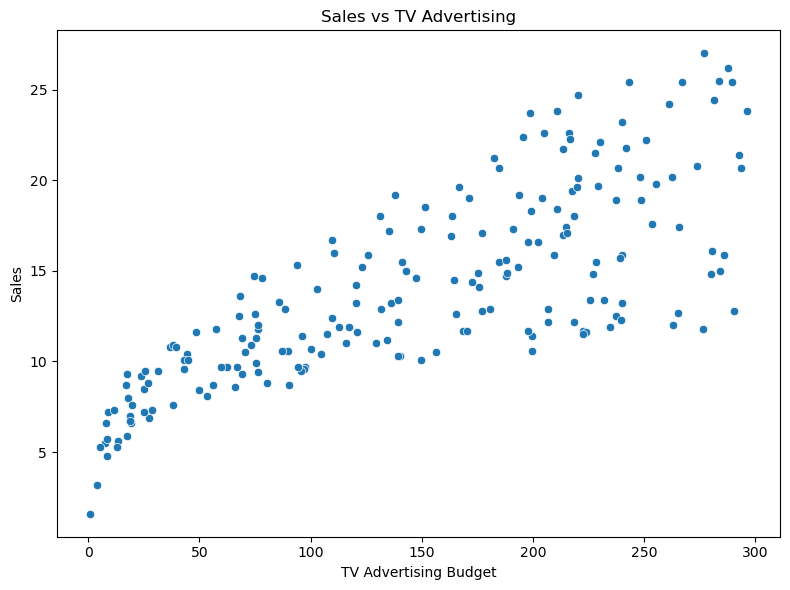

In [11]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="TV",
    y="Sales"
)

plt.title("Sales vs TV Advertising")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [ ]:
### Observation

The scatter plot shows a strong positive relationship between TV advertising
expenditure and Sales. As TV advertising expenditure increases, Sales generally
tend to increase.

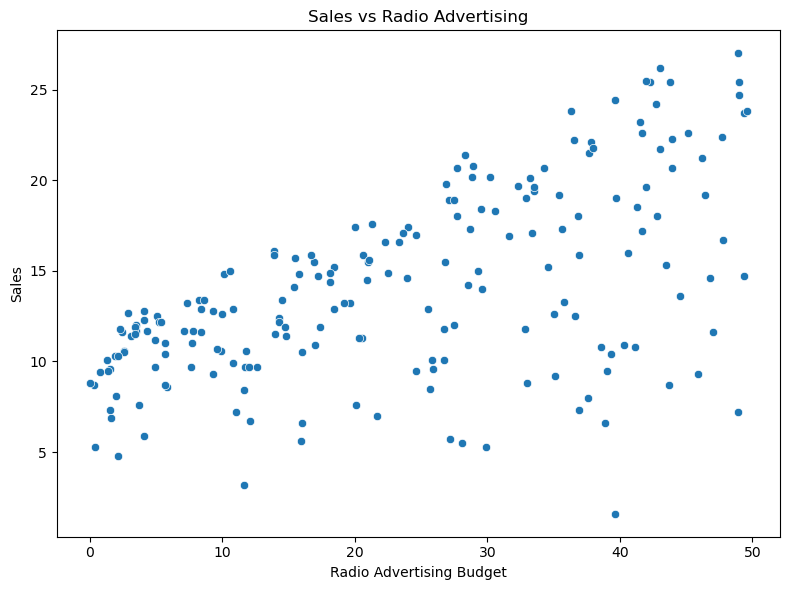

In [12]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Radio",
    y="Sales"
)

plt.title("Sales vs Radio Advertising")
plt.xlabel("Radio Advertising Budget")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [ ]:
### Observation

The scatter plot indicates a positive relationship between Radio advertising
expenditure and Sales. Higher Radio advertising expenditure generally corresponds
to higher Sales.

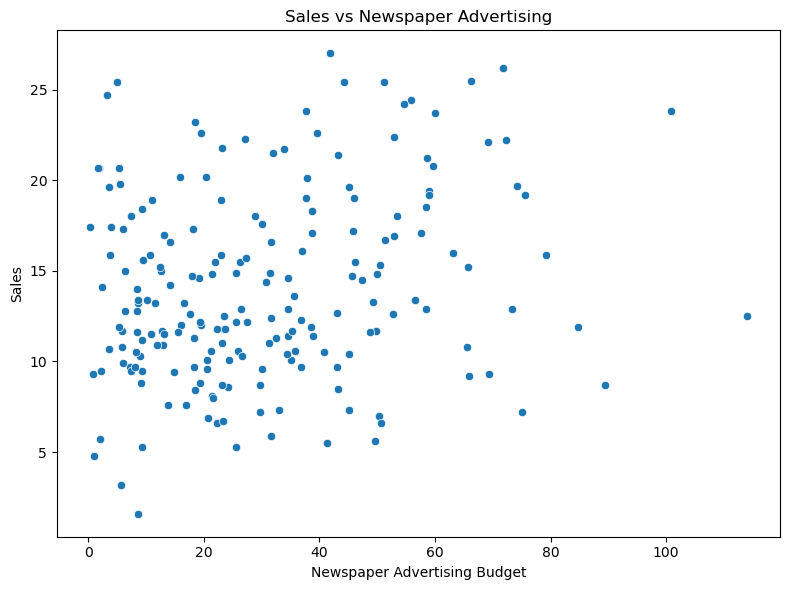

In [13]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Newspaper",
    y="Sales"
)

plt.title("Sales vs Newspaper Advertising")
plt.xlabel("Newspaper Advertising Budget")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [ ]:
### Observation

The relationship between Newspaper advertising expenditure and Sales appears
weaker compared with TV and Radio advertising. The points are more widely
distributed, suggesting a weaker linear relationship.

In [14]:
correlation_matrix = df[
    ["TV", "Radio", "Newspaper", "Sales"]
].corr()

display(correlation_matrix)

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


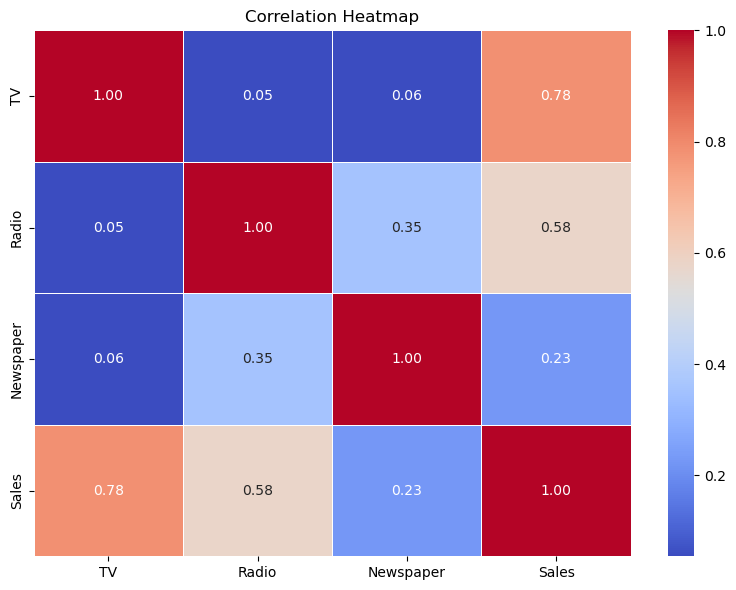

In [15]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
### Observation

The correlation heatmap shows the strength of the relationships between the
advertising channels and Sales.

TV and Radio are expected to show stronger positive correlations with Sales,
whereas Newspaper has a comparatively weaker correlation. This suggests that
TV and Radio expenditure may be more useful predictors of Sales in this dataset.

In [16]:
X = df[
    ["TV", "Radio", "Newspaper"]
]

y = df["Sales"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (200, 3)
Target shape: (200,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 160
Testing samples: 40


In [18]:
# Create Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [19]:
# Predict sales on the test data
y_pred_linear = linear_model.predict(X_test)

print("First 10 actual values:")
print(y_test.values[:10])

print("\nFirst 10 predicted values:")
print(y_pred_linear[:10])

First 10 actual values:
[16.9 22.4 21.4  7.3 24.7 12.6 22.3  8.4 11.5 14.9]

First 10 predicted values:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [20]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("Linear Regression Performance")
print("--------------------------------")
print(f"MAE  : {mae_linear:.4f}")
print(f"RMSE : {rmse_linear:.4f}")
print(f"R²   : {r2_linear:.4f}")

Linear Regression Performance
--------------------------------
MAE  : 1.4608
RMSE : 1.7816
R²   : 0.8994


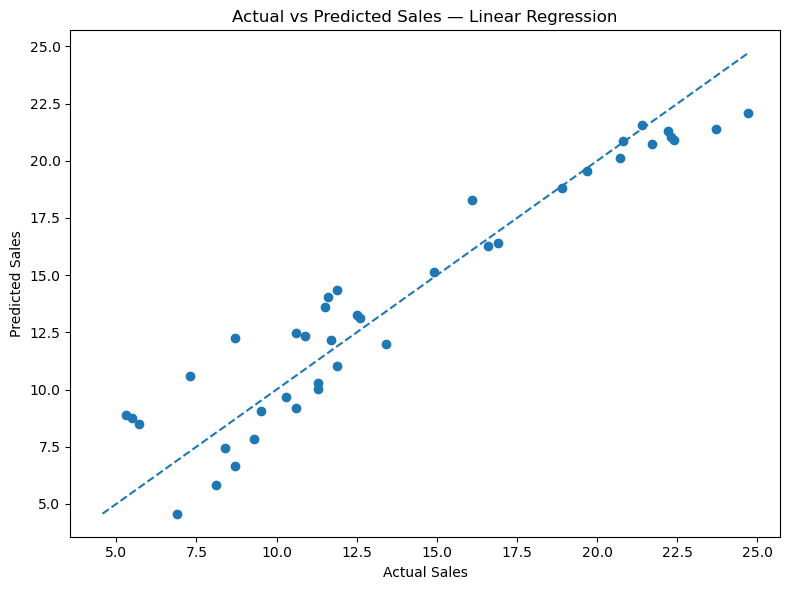

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear
)

# Perfect prediction reference line
min_value = min(y_test.min(), y_pred_linear.min())
max_value = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Sales — Linear Regression")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.tight_layout()
plt.show()

In [ ]:
### Observation

The actual-versus-predicted plot compares the sales values observed in the test
dataset with the values predicted by the Linear Regression model.

Points closer to the diagonal reference line indicate more accurate predictions.

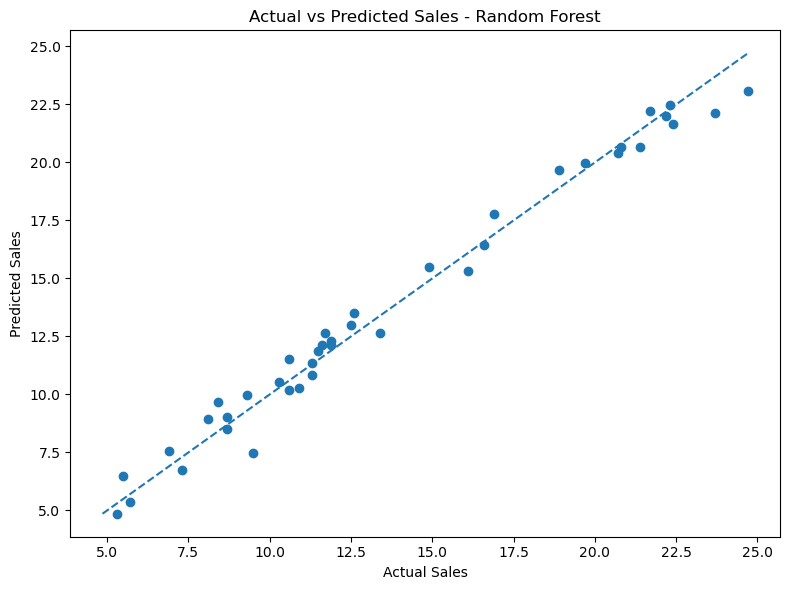

In [36]:
# Actual vs Predicted Sales - Random Forest

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf
)

# Perfect prediction reference line
min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Sales - Random Forest")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.tight_layout()

# Save screenshot-quality figure
plt.savefig(
    "actual_vs_predicted_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
coefficients = pd.DataFrame({
    "Advertising Channel": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

display(
    coefficients.sort_values(
        "Absolute Coefficient",
        ascending=False
    )
)

,Advertising Channel,Coefficient,Absolute Coefficient
1,Radio,0.189195,0.189195
0,TV,0.044730,0.044730
2,Newspaper,0.002761,0.002761


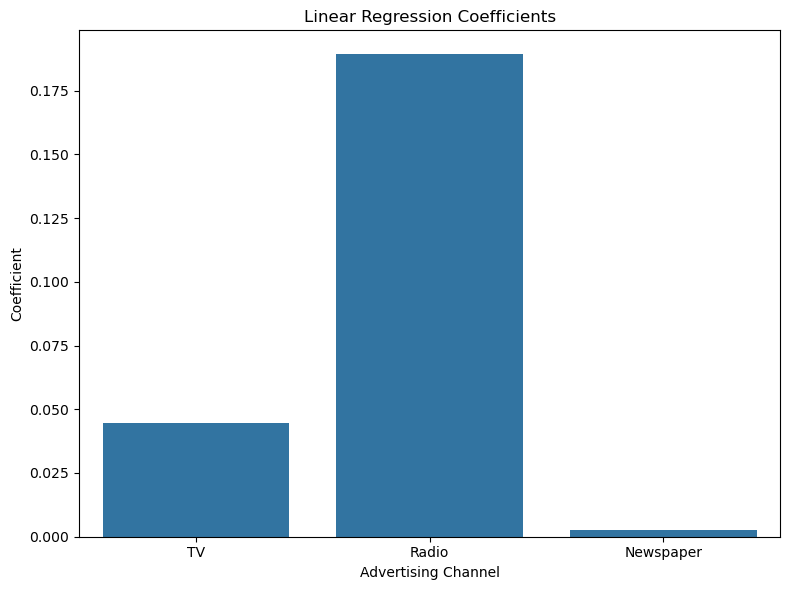

In [24]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=coefficients,
    x="Advertising Channel",
    y="Coefficient"
)

plt.title("Linear Regression Coefficients")
plt.xlabel("Advertising Channel")
plt.ylabel("Coefficient")

plt.tight_layout()
plt.show()

In [ ]:
### Observation

The regression coefficients indicate the estimated contribution of each
advertising channel to Sales while keeping the other advertising variables
constant.

The channel with the largest absolute coefficient has the strongest estimated
linear effect in this model. The coefficient values should be interpreted
alongside the correlation analysis and model assumptions.

In [25]:
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest Regressor trained successfully!")

Random Forest Regressor trained successfully!


In [26]:
y_pred_rf = random_forest_model.predict(X_test)

print("First 10 Random Forest predictions:")
print(y_pred_rf[:10])

First 10 Random Forest predictions:
[17.7615 21.6665 20.6595  6.7395 23.096  13.5155 22.486   9.6625 11.8545
 15.504 ]


In [27]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Performance")
print("--------------------------------")
print(f"MAE  : {mae_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Performance
--------------------------------
MAE  : 0.6287
RMSE : 0.7572
R²   : 0.9818


In [29]:
feature_importance = pd.DataFrame({
    "Advertising Channel": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Advertising Channel,Importance
0,TV,0.624727
1,Radio,0.362119
2,Newspaper,0.013153


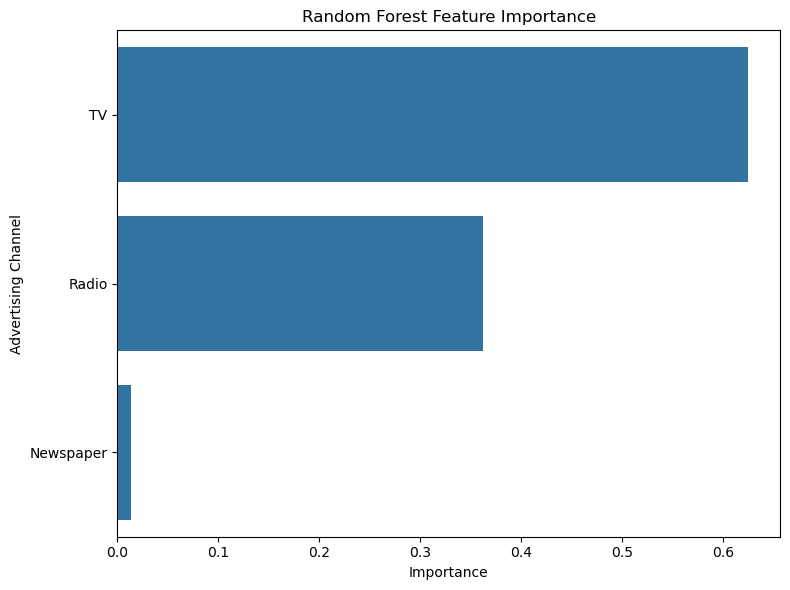

In [30]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Advertising Channel"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.tight_layout()
plt.show()

In [ ]:
### Observation

The Random Forest feature importance shows the relative contribution of each
advertising channel to the model's predictions.

The channel with the highest importance is considered the most influential
feature for the Random Forest model. This result should be compared with the
Linear Regression coefficients and correlation analysis rather than interpreted
as a direct causal effect.

In [31]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R2 Score": [
        r2_linear,
        r2_rf
    ]
})

display(
    model_comparison.round(4)
)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.4608,1.7816,0.8994
1,Random Forest,0.6287,0.7572,0.9818


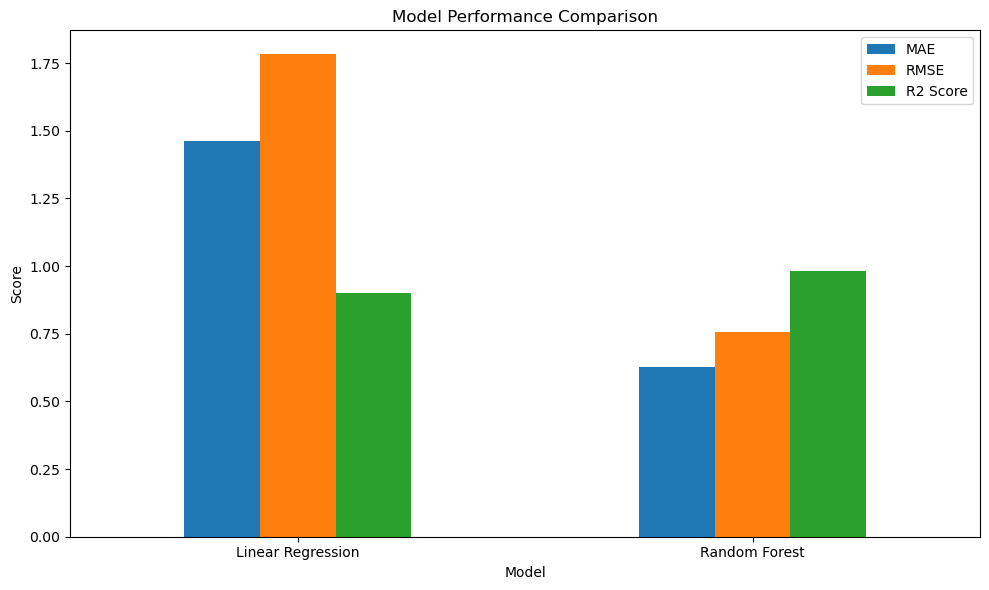

In [27]:
model_comparison_plot = model_comparison.set_index("Model")

model_comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
### Observation

The two regression models are compared using MAE, RMSE, and R².

For MAE and RMSE, lower values indicate smaller prediction errors. For R²,
higher values indicate that the model explains a larger proportion of the
variation in Sales.

The model with the lowest prediction errors and highest R² provides the better
performance on the test dataset.

In [37]:
print("Final Model Comparison")
print("======================")

display(model_comparison.round(4))

print("\nBest Model based on R²:", best_model_name)

Final Model Comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.4608,1.7816,0.8994
1,Random Forest,0.6287,0.7572,0.9818



Best Model based on R²: Random Forest


In [32]:
if r2_rf > r2_linear:
    best_model_name = "Random Forest"
    best_predictions = y_pred_rf
else:
    best_model_name = "Linear Regression"
    best_predictions = y_pred_linear

residuals = y_test - best_predictions

print("Best Model:", best_model_name)
print("Residual Mean:", residuals.mean())

Best Model: Random Forest
Residual Mean: -0.027837499999995408


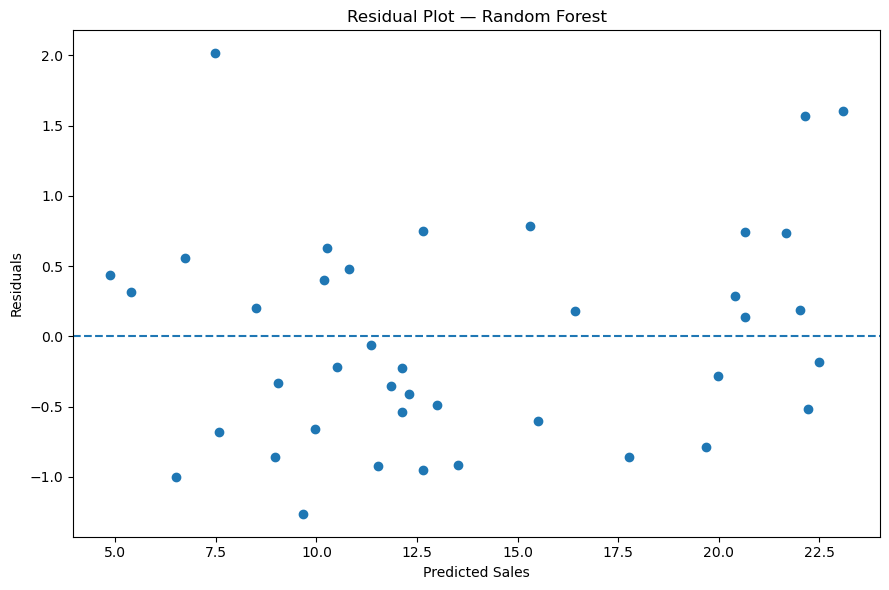

In [33]:
plt.figure(figsize=(9, 6))

plt.scatter(
    best_predictions,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    f"Residual Plot — {best_model_name}"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

In [ ]:
### Observation

The residual plot shows the prediction errors of the selected best-performing
model.

Ideally, residuals should be distributed randomly around zero without a clear
systematic pattern. A strong pattern or increasing spread may indicate that the
model does not fully capture the underlying relationship in the data.

In [34]:
print("Final Model Comparison")
print("======================")

display(model_comparison.round(4))

print("\nBest Model based on R²:", best_model_name)

Final Model Comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.4608,1.7816,0.8994
1,Random Forest,0.6287,0.7572,0.9818



Best Model based on R²: Random Forest


In [ ]:
# Conclusion

This project developed machine-learning models for predicting Sales using
advertising expenditure on TV, Radio, and Newspaper.

The dataset was explored and cleaned before applying regression techniques.
Exploratory visualizations and correlation analysis were used to understand the
relationships between advertising expenditure and Sales.

Two regression models were evaluated:

1. Linear Regression
2. Random Forest Regressor

The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared
Error (RMSE), and R² score.

The model comparison identifies the better-performing model based on lower
prediction errors and a higher R² score.

Feature analysis was also performed to identify the advertising channel that
contributes most strongly to the model's predictions.

Finally, residual analysis was used to assess the distribution of prediction
errors and identify potential patterns that may indicate limitations of the
model.

Overall, the project demonstrates how exploratory data analysis, regression
models, evaluation metrics, and feature analysis can be combined to build a
Sales Prediction system using Python.